In [50]:
import nltk
nltk.download('vader_lexicon')

#VADER sentiment analyzer was selected because it is lightweight, reproducible and designed for short textual content.


import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("test(in).csv")
print(df.head())
print(df.columns)

                                        Subject  \
0                          EnronOptions Update!   
1                                  (No Subject)   
2  Phone Screen  Interview - Shannon L. Burnham   
3                         RE: My new work email   
4                                           Bet   

                                                body       date  \
0  EnronOptions Announcement\n\n\nWe have updated...  5/10/2010   
1  Marc,\n\nUnfortunately, today is not going to ...  7/29/2010   
2  When: Wednesday, June 06, 2001 10:00 AM-11:00 ...  7/25/2011   
3  we were thinking papasitos (we can meet somewh...  3/25/2010   
4  Since you never gave me the $20 for the last t...  5/21/2011   

                      from  
0     sally.beck@enron.com  
1      eric.bass@enron.com  
2     sally.beck@enron.com  
3  johnny.palmer@enron.com  
4  lydia.delgado@enron.com  
Index(['Subject', 'body', 'date', 'from'], dtype='object')


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [51]:
#task 1
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def label_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["body"].apply(label_sentiment)

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [52]:
print(df.columns)

Index(['Subject', 'body', 'date', 'from', 'sentiment'], dtype='object')


In [53]:
#task2
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Subject    2191 non-null   object
 1   body       2191 non-null   object
 2   date       2191 non-null   object
 3   from       2191 non-null   object
 4   sentiment  2191 non-null   object
dtypes: object(5)
memory usage: 85.7+ KB


,Subject,body,date,from,sentiment
count,2191,2191,2191,2191,2191
unique,1251,1539,690,10,3
top,(No Subject),\n\n,7/1/2011,lydia.delgado@enron.com,Positive
freq,141,21,9,284,1528


<Axes: xlabel='sentiment'>

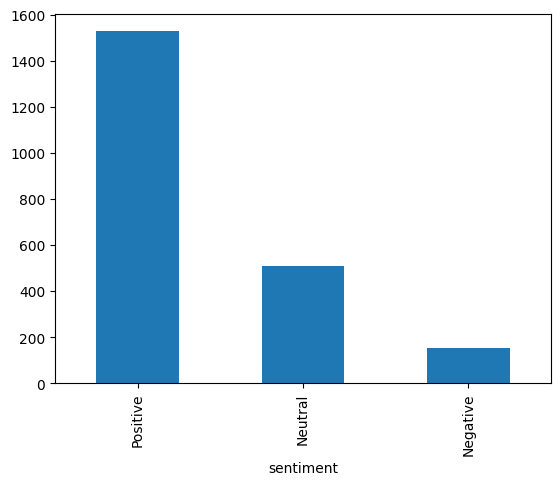

In [54]:
df["sentiment"].value_counts().plot(kind="bar")

In [55]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

<Axes: xlabel='month'>

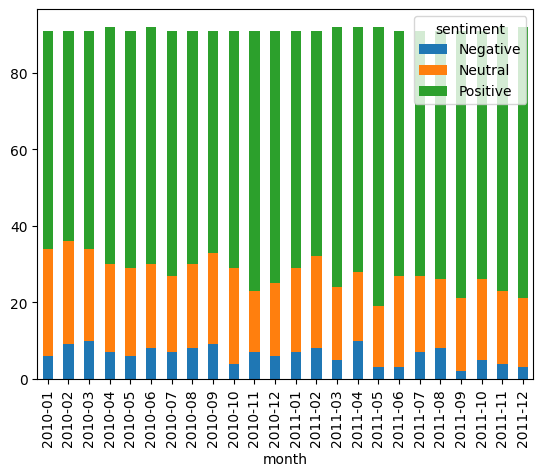

In [56]:
df.groupby(["month", "sentiment"]).size().unstack().plot(kind="bar", stacked=True)

In [57]:
#Task 2: EDA Conclusions (Sentiment Over Time)

#1. Overall Sentiment Distribution

#The dataset is heavily skewed toward Positive sentiment across all months.
#Neutral sentiment is consistently the second largest category.
#Negative sentiment remains very low and stable throughout the timeline.

#2. Time Trend Observation

#There is no major seasonal or structural shift in sentiment over time.
#Month-to-month variations exist, but they are minor fluctuations rather than trends.
#The overall sentiment pattern remains highly stable from 2010 to 2011.

#3. Employee Engagement Insight

#High proportion of positive messages suggests generally healthy employee communication.
#Low negative sentiment indicates low visible dissatisfaction or conflict signals.
#Neutral messages suggest a significant portion of informational or factual communication.

#4. Risk & Anomaly Check

#No sharp spikes in negative sentiment were observed in any month → no crisis periods detected.
#No sudden drops in positive sentiment → no major engagement breakdowns.

#5. Key Insights

#The organization shows a stable and positive communication culture.
#Sentiment distribution is consistent over time, indicating steady employee behavior patterns rather than changing morale trends.

In [58]:
df["employee"] = df["from"]

In [59]:
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

In [60]:
#task 3
score_map = {"Positive": 1, "Negative": -1, "Neutral": 0}
df["score"] = df["sentiment"].map(score_map)

# create required columns
df["employee"] = df["from"]
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

monthly_scores = df.groupby(["employee", "month"])["score"].sum().reset_index()

Top Positive Employees
                        employee    month  score
120      kayne.coulter@enron.com  2010-01     13
48           eric.bass@enron.com  2010-01      9
144      lydia.delgado@enron.com  2010-01      9
73         john.arnold@enron.com  2010-02     11
97       johnny.palmer@enron.com  2010-02     10
..                           ...      ...    ...
94         john.arnold@enron.com  2011-11     10
22   bobette.riner@ipgdirect.com  2011-11      9
71           eric.bass@enron.com  2011-12     12
191     patti.thompson@enron.com  2011-12     12
167      lydia.delgado@enron.com  2011-12     10

[72 rows x 3 columns]


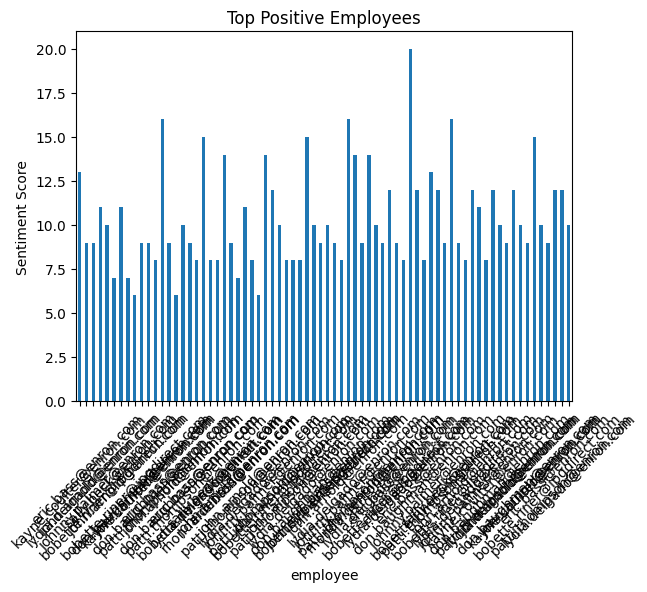

In [86]:
#task 4
top_positive = monthly_scores.sort_values(
    ["month", "score", "employee"],
    ascending=[True, False, True]
).groupby("month").head(3)

print("Top Positive Employees")
print(top_positive)


top_positive.plot(
    kind="bar",
    x="employee",
    y="score",
    legend=False
)

plt.title("Top Positive Employees")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()


Top Negative Employees
                        employee    month  score
0    bobette.riner@ipgdirect.com  2010-01      1
96       johnny.palmer@enron.com  2010-01      1
192      rhonda.denton@enron.com  2010-01      1
121      kayne.coulter@enron.com  2010-02      1
145      lydia.delgado@enron.com  2010-02      1
..                           ...      ...    ...
214      rhonda.denton@enron.com  2011-11      2
46        don.baughman@enron.com  2011-11      5
119      johnny.palmer@enron.com  2011-12      2
23   bobette.riner@ipgdirect.com  2011-12      3
95         john.arnold@enron.com  2011-12      4

[72 rows x 3 columns]


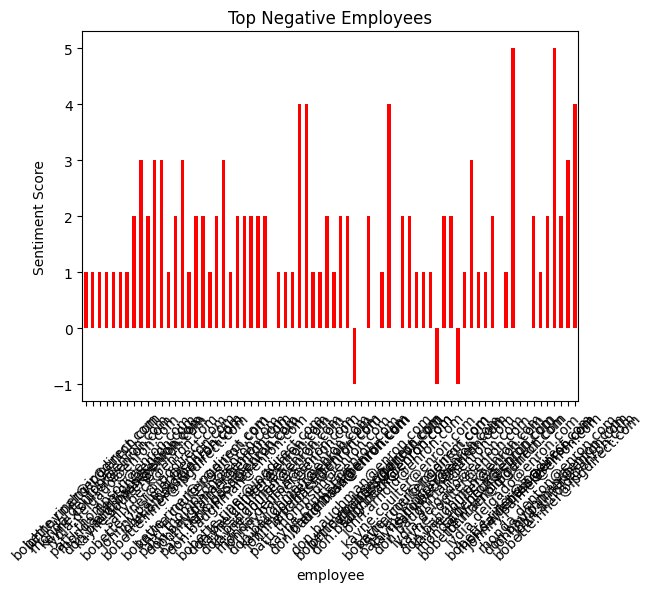

In [88]:
top_negative = monthly_scores.sort_values(
    ["month", "score", "employee"],
    ascending=[True, True, True]
).groupby("month").head(3)

print("\nTop Negative Employees")
print(top_negative)

top_negative.plot(
    kind="bar",
    x="employee",
    y="score",
    legend=False,
    color="red"
)

plt.title("Top Negative Employees")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45)
plt.show()

In [63]:
#task 5
df = df.sort_values(["employee", "date"])
df["is_negative"] = (df["sentiment"] == "Negative").astype(int)

In [64]:
df["is_negative"] = (df["sentiment"] == "Negative").astype(int)

In [65]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["from", "date"]).reset_index(drop=True)

In [66]:
df = df.sort_values(["employee", "date"]).copy()
df["is_negative"] = (df["sentiment"] == "Negative").astype(int)

df["rolling_neg"] = (
    df.set_index("date")
      .groupby("employee")["is_negative"]
      .rolling("30D")
      .sum()
      .to_numpy()
)

In [67]:
flight_risk = df[df["rolling_neg"] >= 4]["employee"].unique()


Flight Risk Employees
['bobette.riner@ipgdirect.com' 'don.baughman@enron.com'
 'johnny.palmer@enron.com' 'sally.beck@enron.com']


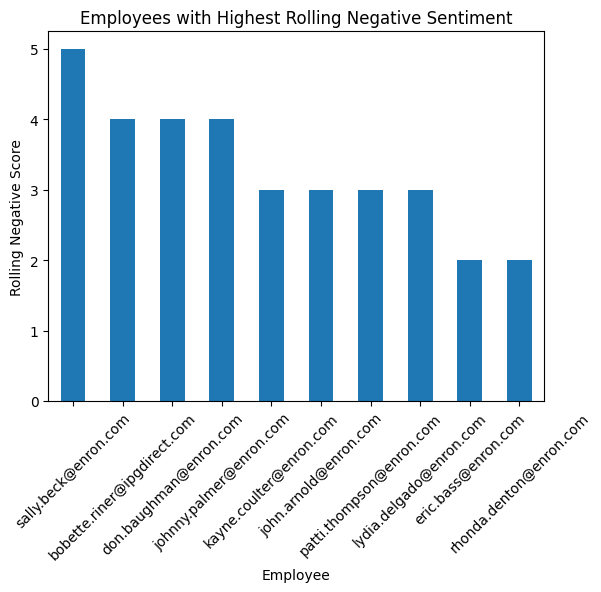

In [89]:
risk = (
    df.groupby("employee")["rolling_neg"]
      .max()
      .sort_values(ascending=False)
      .head(10)
)

print("\nFlight Risk Employees")
print(flight_risk)

risk.plot(kind="bar")

plt.title("Employees with Highest Rolling Negative Sentiment")
plt.xlabel("Employee")
plt.ylabel("Rolling Negative Score")
plt.xticks(rotation=45)
plt.show()

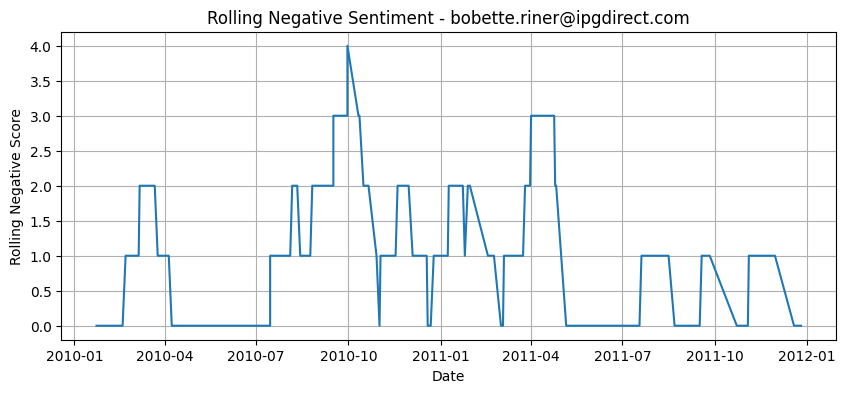

In [75]:
#Rolling Negativity of One Employee
employee_name = df["employee"].iloc[0]

emp = df[df["employee"] == employee_name]

plt.figure(figsize=(10,4))
plt.plot(emp["date"], emp["rolling_neg"])
plt.title(f"Rolling Negative Sentiment - {employee_name}")
plt.xlabel("Date")
plt.ylabel("Rolling Negative Score")
plt.grid(True)
plt.show()

In [68]:
#task 6
df["msg_length"] = df["body"].apply(lambda x: len(str(x)))
df["word_count"] = df["body"].apply(lambda x: len(str(x).split()))

In [69]:
df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.to_period("M")

df["msg_length"] = df["body"].astype(str).str.len()
df["word_count"] = df["body"].astype(str).str.split().str.len()

model_df = df.groupby(["from", "month"]).agg({
    "score": "sum",
    "msg_length": "mean",
    "word_count": "mean"
}).reset_index()

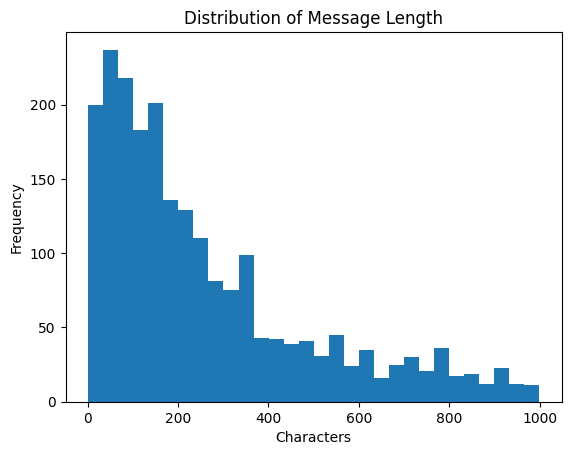

In [78]:
#msg length distribution
plt.hist(df["msg_length"], bins=30)

plt.title("Distribution of Message Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

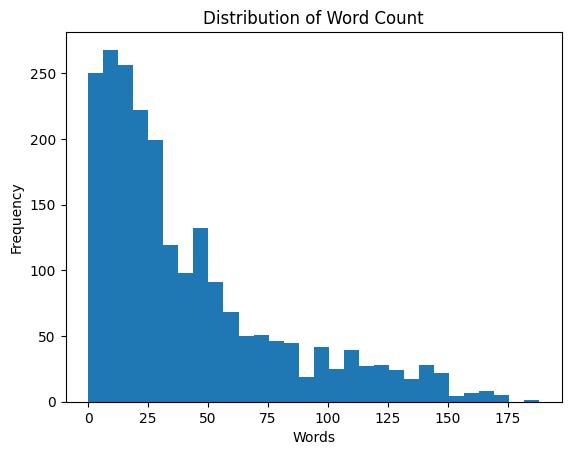

In [77]:
#word count distribution
plt.hist(df["word_count"], bins=30)

plt.title("Distribution of Word Count")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

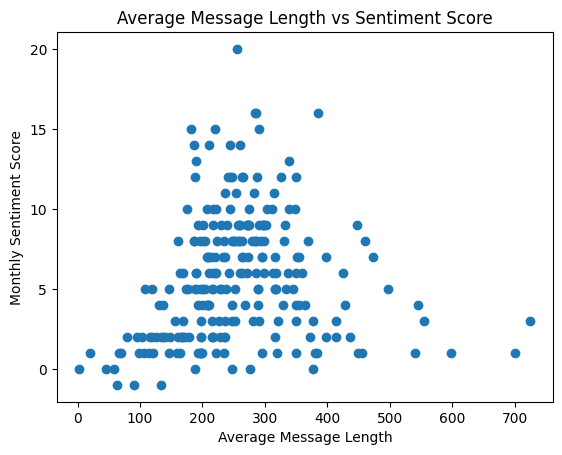

In [80]:
#Average Message Length vs Sentiment Score
plt.scatter(
    model_df["msg_length"],
    model_df["score"]
)

plt.title("Average Message Length vs Sentiment Score")
plt.xlabel("Average Message Length")
plt.ylabel("Monthly Sentiment Score")
plt.show()

In [70]:
#training the model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = model_df[["msg_length", "word_count"]]
y = model_df["score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [71]:
#evaluation
from sklearn.metrics import mean_squared_error, r2_score

pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MSE: 13.109728610532501
R2: -0.10304987469111793


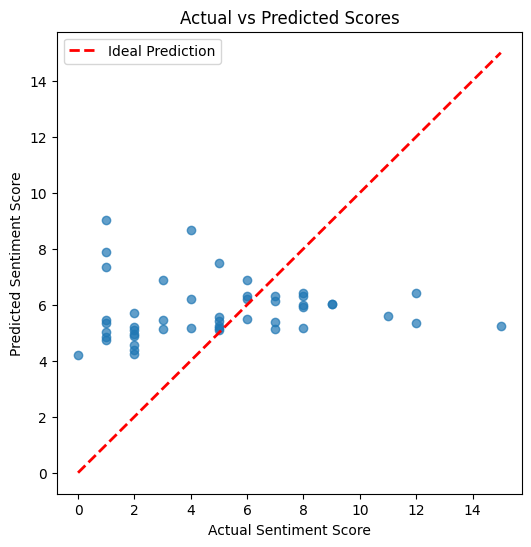

In [81]:
#actual vs predicted plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2,
    label="Ideal Prediction"
)

plt.xlabel("Actual Sentiment Score")
plt.ylabel("Predicted Sentiment Score")
plt.title("Actual vs Predicted Scores")
plt.legend()

plt.show()

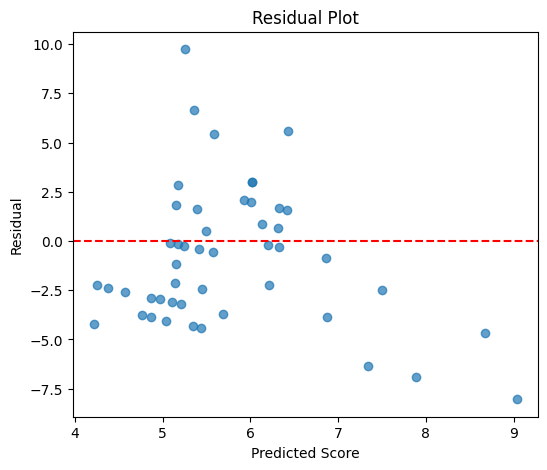

In [82]:
#residual plot
residuals = y_test - pred

plt.figure(figsize=(6,5))

plt.scatter(pred, residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [83]:
#feature importance
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df

,Feature,Coefficient
0,msg_length,0.033391
1,word_count,-0.161139


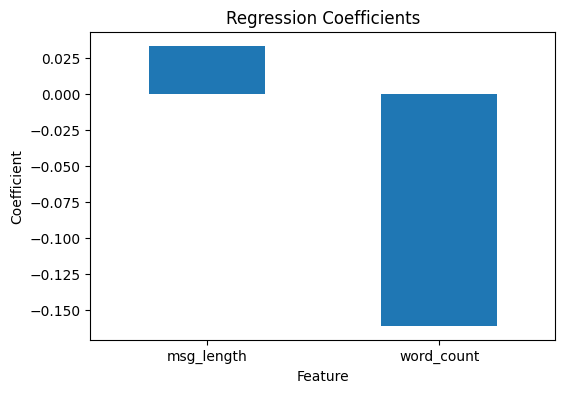

In [84]:
coef_df.plot(
    kind="bar",
    x="Feature",
    y="Coefficient",
    legend=False,
    figsize=(6,4)
)

plt.title("Regression Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=0)

plt.show()

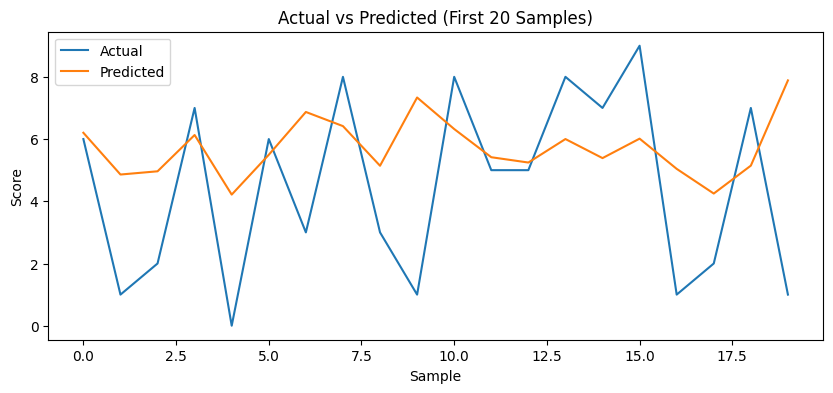

In [85]:
#predicted vs actual line plot
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": pred
}).reset_index(drop=True)

comparison.head(20).plot(figsize=(10,4))

plt.title("Actual vs Predicted (First 20 Samples)")
plt.xlabel("Sample")
plt.ylabel("Score")

plt.show()

In [ ]:
#The regression model was trained using average message length and average word count to predict monthly sentiment scores.
#The model achieved an R² score of approximately -0.10, indicating that these two textual features alone do not adequately
#explain variations in employee sentiment.
#This suggests that additional features—such as email frequency, response time, subject keywords, or
#semantic embeddings would likely improve predictive performance.